## Project 17: Link prediction 2

In [80]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import powerlaw

Käytetty dataset: the Wikipedia vote network dataset. Saatavilla: https://snap.stanford.edu/data/wiki-Vote.html
Luodaan suunnattu graafi datasetistä.

In [81]:
G = nx.read_edgelist(
    "Wiki-Vote.txt",
    comments="#",
    nodetype=int,
    create_using=nx.DiGraph()
)

print(nx.number_of_nodes(G))
print(nx.number_of_edges(G))

7115
103689


Tehdään 100:n noden sample graafista ja visualisoidaan se.
TODO: paranna layoutia

<Figure size 640x480 with 0 Axes>

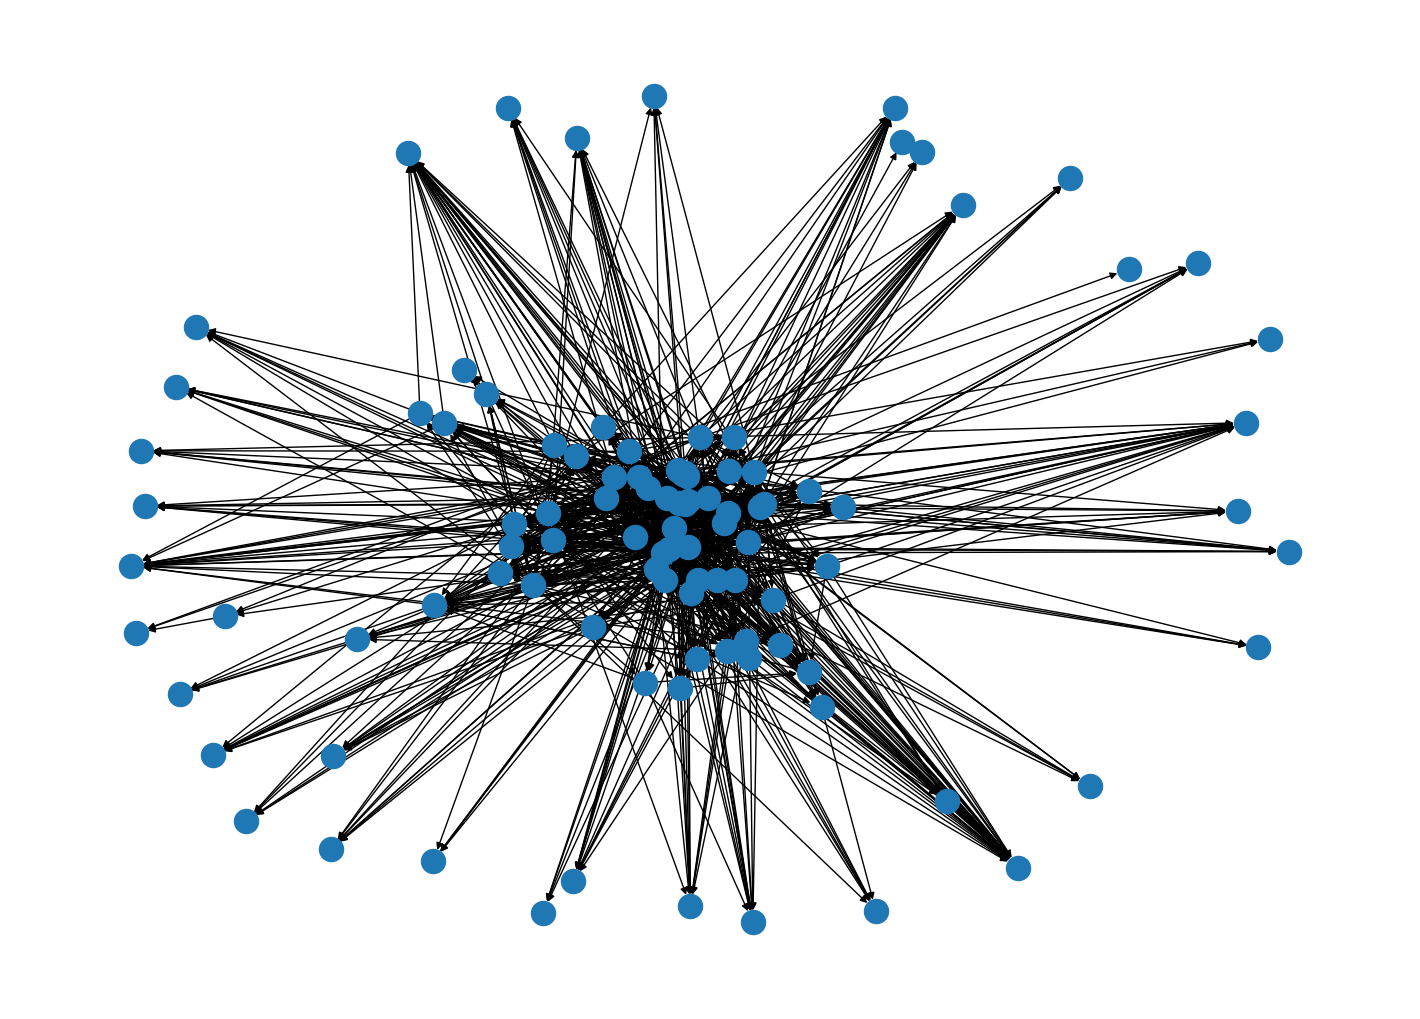

In [12]:
sample = G.subgraph(list(G.nodes())[:100])

plt.clf()
pos = nx.spring_layout(sample)
plt.figure(figsize=(14, 10))
nx.draw(sample, pos, with_labels=False)
plt.show()


Tehdään adjancency matrix ja tallenetaan excel-tiedostoon
(tehty pelkästä samplesta, koska koko adjacency matrix olisi liian suuri)

In [13]:
adjacency_matrix = nx.adjacency_matrix(sample)

pandas_dataframe = pd.DataFrame(adjacency_matrix.toarray())
pandas_dataframe.to_excel("adjacency_matrix.xlsx")

Task2: TODO tarkista mitä tässä pitäisi tehdä

In [ ]:
#TODO

In-degree ja out-degree jakaumat

(array([5.90e+03, 4.64e+02, 2.55e+02, 1.25e+02, 9.90e+01, 6.60e+01,
        4.60e+01, 2.50e+01, 3.10e+01, 1.40e+01, 1.50e+01, 1.20e+01,
        1.30e+01, 9.00e+00, 3.00e+00, 8.00e+00, 4.00e+00, 8.00e+00,
        2.00e+00, 2.00e+00, 2.00e+00, 2.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 1.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00,
        0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00]),
 array([  0.  ,  17.86,  35.72,  53.58,  71.44,  89.3 , 107.16, 125.02,
        142.88, 160.74, 178.6 , 196.46, 214.32, 232.18, 250.04, 267.9 ,
        285.76, 303.62, 321.48, 339.34, 357.2 , 375.06, 392.92, 410.78,
        428.64, 446.5 , 464.36, 482.22, 500.08, 517.94, 535.8 , 553.66,
        571.52, 589.38, 607.24, 625.1 , 642.96, 660.82, 678.68, 696.54,
        714.4 , 732.26, 750.12, 767.98, 785.84, 803.7 , 821.56, 83

<Figure size 640x480 with 0 Axes>

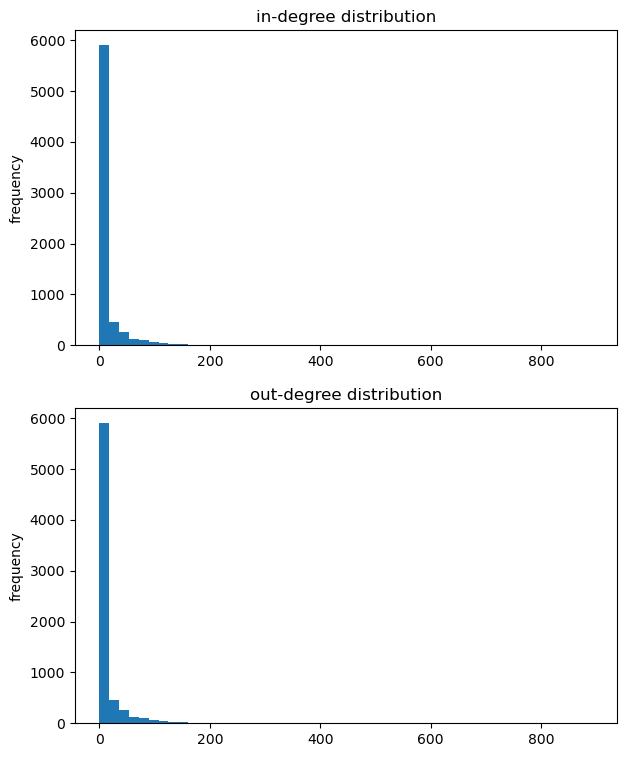

In [57]:
in_degrees = [d for n,d in G.in_degree()]
out_degrees = [d for n,d in G.out_degree()]

plt.clf()

plt.figure(figsize=(7, 9))

plt.subplot(2,1,1)
plt.title("in-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

plt.subplot(2,1,2)
plt.title("out-degree distribution")
plt.ylabel("frequency")
plt.hist(out_degrees, bins=50)

Power-law distribution

<Figure size 640x480 with 0 Axes>

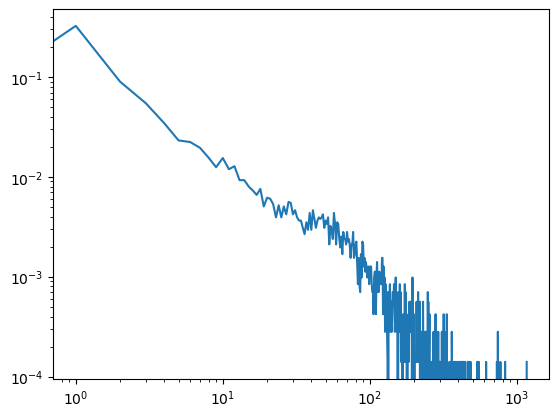

In [ ]:

# compute the fraction of nodes (p_k) having degree k

histogram = nx.degree_histogram(G)

number_of_nodes = nx.number_of_nodes(G)

p_k = np.array(histogram) / number_of_nodes

# plot a log-log graph, where
#   x-axis: ln (k)
#   y-axis: ln (p_k)

k = np.arange(len(histogram))

plt.clf()
plt.figure()
plt.loglog(k, p_k)
plt.show()


Goodness of fit
Source: https://github.com/powerlaw-devs/powerlaw/tree/master

alpha =  4.14869966168172
xmin =   248.0
R = -0.09253396147097259
p = 0.783987231790295


Calculating best minimal value for power law fit


<Figure size 640x480 with 0 Axes>

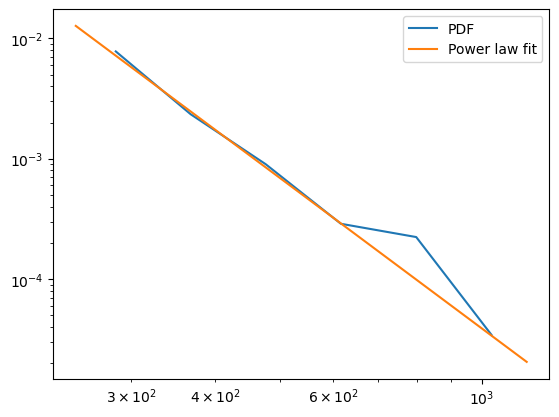

In [92]:
degrees = [d for n, d in G.degree()]

fit = powerlaw.Fit(degrees)

print("alpha = ", fit.power_law.alpha)
print("xmin =  ", fit.power_law.xmin)

R, p = fit.distribution_compare('power_law', 'lognormal')

print("R =", R)
print("p =", p)


plt.clf()

fig, ax = plt.subplots()

fit.plot_pdf(ax=ax, label='PDF')
fit.power_law.plot_pdf(ax=ax, label='Power law fit')

plt.legend()
plt.show()


--> noudattaa powerlaw 90% luottamusvälillä, kun degree > 248
TODO tämän selittäminen tarkemmin